# Phidl experiments
----------

In [37]:
import gdspy

from phidl import Device, Layer
import phidl.geometry as pg
from phidl import quickplot as qp
from phidl import set_quickplot_options as set_qp_options

from phidl.device_layout import Polygon

import numpy as np

## 1. Quick plotting

In [38]:
import matplotlib
matplotlib.use("QtAgg")

In [39]:
print(matplotlib.get_backend())

QtAgg


In [40]:
# --- make a simple device ---
D = Device("demo")

rect = pg.rectangle(size=(20, 10), layer=(1, 0))
D.add_ref(rect)

# optional: add ports so you can see them
D.add_port(
    name="p1",
    midpoint=(0, 5),
    width=10,
    orientation=180,
)

# --- configure quickplot behavior ---
set_qp_options(
    new_window=True,     # open a new window
    blocking=True,      # don't halt script execution
    show_ports=True,     # draw ports
    show_subports=True, # don't show ports of references
)

# --- show it ---
qp(D)

## 2. Test device/cell hierarchy

In [41]:
%matplotlib inline

In [42]:
print(matplotlib.get_backend())

module://matplotlib_inline.backend_inline


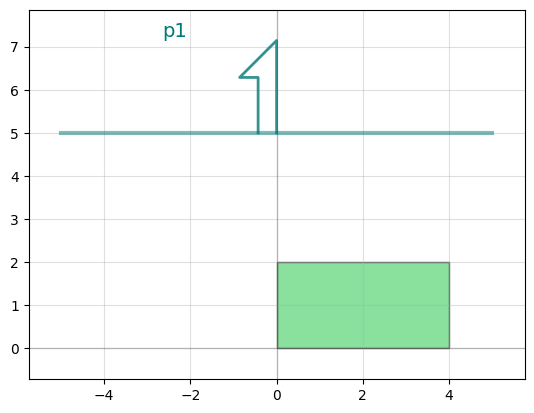

In [43]:
Top_Device = Device('TOP')

Sub_Device = Device('Sub device')

rectangle_ref = Sub_Device << pg.rectangle()

Sub_Device.add_port(
    name="p1",
    midpoint=(0, 5),
    width=10,
    orientation=90,
)

Top_Device << Sub_Device

qp(Top_Device)

In [44]:
Top_Device.write_gds('Test_Hierarchy.gds')

'Test_Hierarchy.gds'

In [45]:
import gdspy
from collections import Counter

In [46]:
def inspect_gds_hierarchy(gds_path):
    lib = gdspy.GdsLibrary(infile=gds_path)

    tops = lib.top_level()
    print("Top-level cells:", [c.name for c in tops])
    top = tops[0]  # pick the first top cell (change if needed)

    # --- build direct reference map: cell -> Counter(referenced_cell -> count) ---
    edges = {}
    for name, cell in lib.cells.items():
        ctr = Counter()
        for ref in (cell.references or []):
            tgt = getattr(ref, "ref_cell", None)
            if tgt is not None:
                ctr[tgt.name] += 1
        edges[name] = ctr

    print("\nHierarchy:")
    print_tree(top.name, edges)

# --- pretty-print hierarchy tree ---
def print_tree(name, edges, prefix="", stack=None):
    if stack is None:
        stack = set()
    if name in stack:
        print(prefix + name + "  (cycle)")
        return

    print(prefix + name)
    stack.add(name)

    kids = edges.get(name, Counter())
    items = sorted(kids.items(), key=lambda kv: (-kv[1], kv[0]))

    for i, (kid, n) in enumerate(items):
        last = (i == len(items) - 1)
        branch = "└── " if last else "├── "
        next_prefix = prefix + ("    " if last else "│   ")
        print(prefix + branch + f"{kid}  x{n}")
        print_tree(
            kid,
            edges,
            prefix=next_prefix,
            stack=stack
        )

    stack.remove(name)

In [47]:
# --- load GDS ---
gds_path = "Test_Hierarchy.gds"

inspect_gds_hierarchy(gds_path)

Top-level cells: ['toplevel']

Hierarchy:
toplevel
└── Sub device  x1
    Sub device
    └── rectangle  x1
        rectangle


## 3. Device and device reference

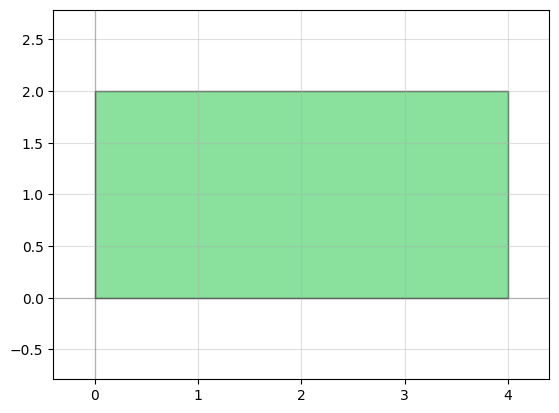

In [48]:
D = Device()
Sub_Device = pg.rectangle()

sub_device_ref = D << Sub_Device

qp(D)

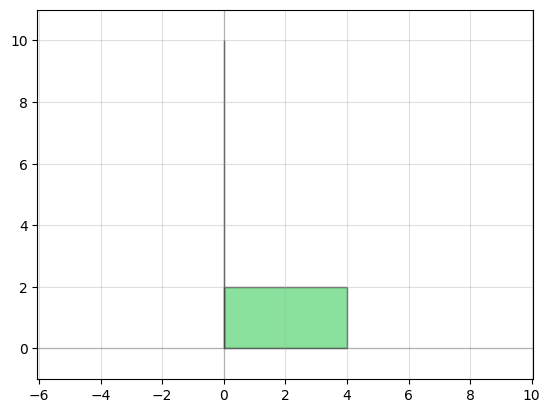

In [49]:
Sub_Device.add_polygon(points=[(0, 0), (0, 10)])

qp(D)

Modifying the sub device also modifies the top level device `D` that contains this sub device! 

In [50]:
D.get_dependencies()

{Device (name "rectangle" (uid 37), ports [], aliases [], 2 polygons, 0 references)}

In [51]:
for Dev in D.get_dependencies():

    Device_Dependency: Device = Dev

    print(f'Is the dependency from get_dependency the same as Sub_Device? {Device_Dependency is Sub_Device}')

Is the dependency from get_dependency the same as Sub_Device? True


## 4. Compass

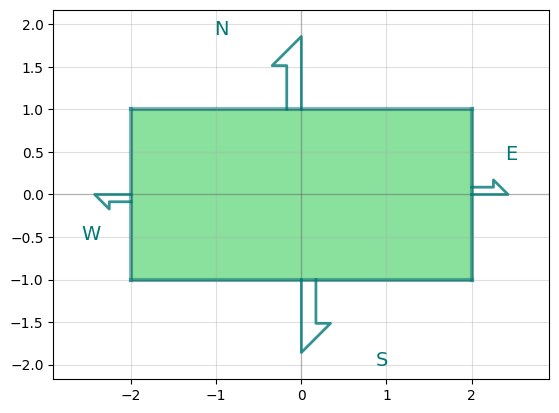

In [52]:
Compass_Device = Device('Compass')

Compass_Device << pg.compass()
qp(Compass_Device)

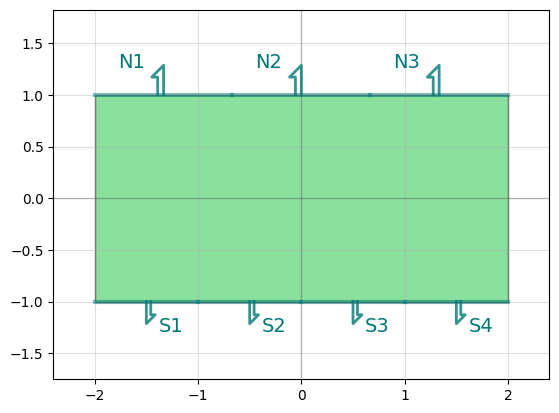

In [53]:
Multi_Compass_Device = Device('Compass')

Multi_Compass_Device << pg.compass_multi()
qp(Multi_Compass_Device)

## 4. Remove

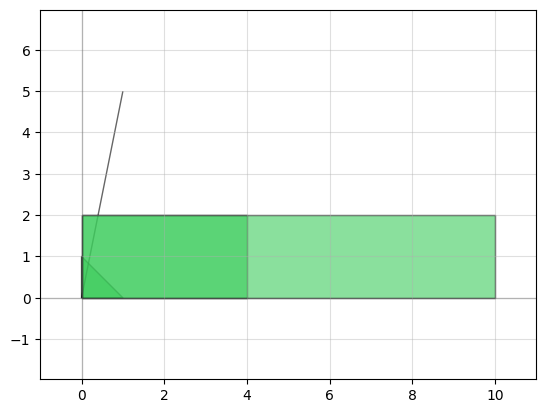

In [54]:
D = Device("MY_DEVICE")

R1 = D << pg.rectangle()

R2 = D << pg.rectangle(size=(10,2))

D.add_polygon(points=[(0,0), (1,0), (0,1)])

D.add_polygon(points=[(0,0), (1,5)], layer=Layer())


qp(D)

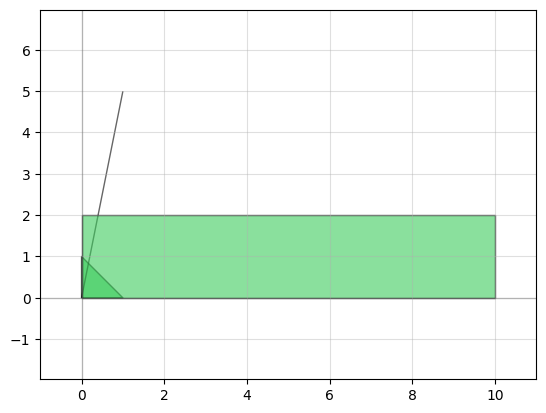

In [55]:
D.remove(R1)
qp(D)

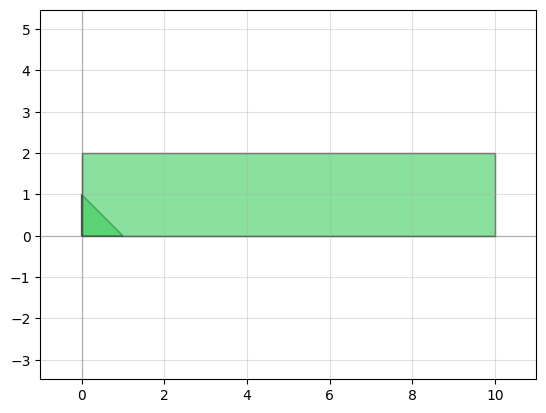

In [56]:
def remove_poly_callable(points, layer, datatype):

    if len(points) == 2:
        return True
    else:
        False

D.remove_polygons(remove_poly_callable)

qp(D)

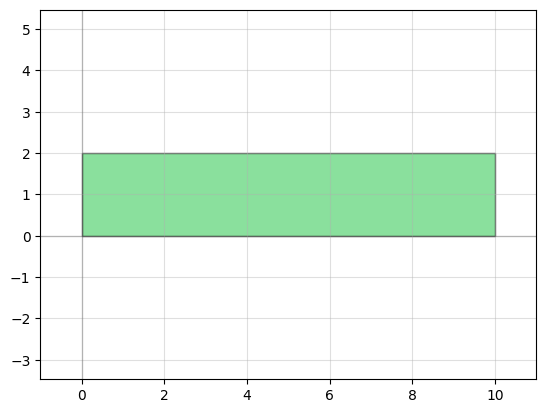

In [57]:
D.remove_polygons(lambda pts, layer, datatype: True)

qp(D)

This rectangle is a sub device, i.e. a sub cell. On the level of the top device/cell `D` its polygons are not exposed to `remove_polygons()`!

Hence, it is still here.

## 5. Single Pass Lines/Zero Width Path

c:\Users\aw270929\Miniconda3\envs\phidl\lib\site-packages\gdspy\path.py:662: RuntimeWarning: invalid value encountered in double_scalars
  u0 = (v1[1] * dx - v1[0] * dy) / den
c:\Users\aw270929\Miniconda3\envs\phidl\lib\site-packages\gdspy\path.py:663: RuntimeWarning: invalid value encountered in double_scalars
  u1 = (v0[1] * dx - v0[0] * dy) / den


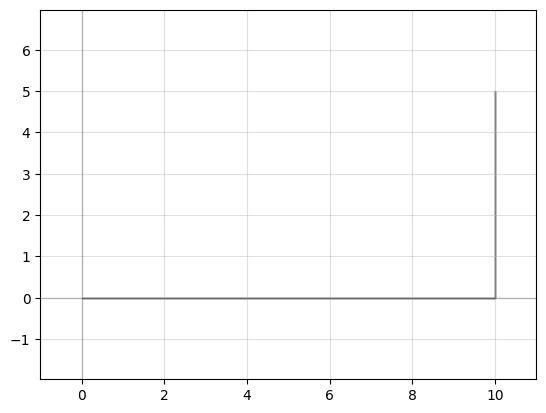

'phidl_with_flexpath.gds'

In [58]:
# --- Build PHIDL device (PHIDL Devices behave like gdspy Cells for storage/export)
D = Device("MY_DEVICE")

# --- Make a FlexPath (width=0 for centerline)
# gdsii_path=True encourages writing as a true GDSII PATH when possible
fp = gdspy.FlexPath(
    [(0, 0), (10, 0), (10, 5)],   # spine points
    width=0,                      # zero-width centerline
    layer=1,
    datatype=0,
    ends="flush",
    gdsii_path=True
)

# --- Add the gdspy FlexPath into the PHIDL Device
# This uses the underlying gdspy Cell storage convention (Cell.paths list). :contentReference[oaicite:3]{index=3}
D.add(fp)

qp(D)

# --- Write to GDS using PHIDL (creates a library and serializes)
# cellname controls the top-level cell name PHIDL uses when writing. :contentReference[oaicite:4]{index=4}
out = "phidl_with_flexpath.gds"
D.write_gds(out, cellname="TOP")



In [59]:
# --- Verify by re-loading with gdspy and counting paths
lib = gdspy.GdsLibrary(infile=out)

total_paths = sum(len(cell.paths) for cell in lib.cells.values())
print("Cells in file:", list(lib.cells.keys()))
print("Total paths in file:", total_paths)

# Optional: print per-cell path counts
for name, cell in lib.cells.items():
    if len(cell.paths):
        print(f"{name}: paths={len(cell.paths)}")

Cells in file: ['TOP']
Total paths in file: 1
TOP: paths=1


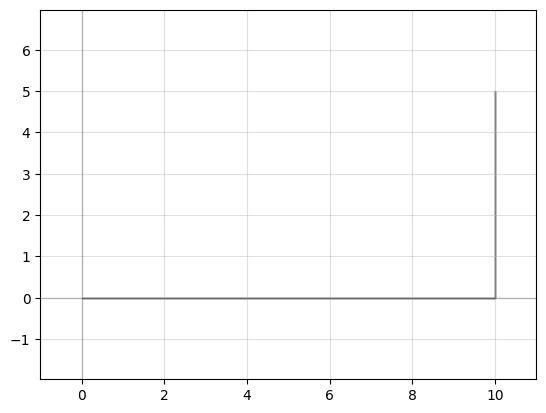

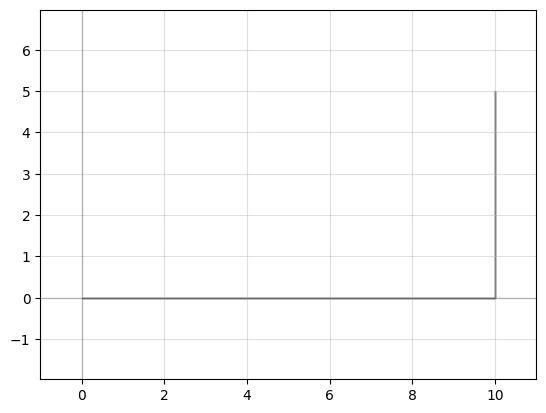

In [60]:
qp(D)
qp(D.mirror())

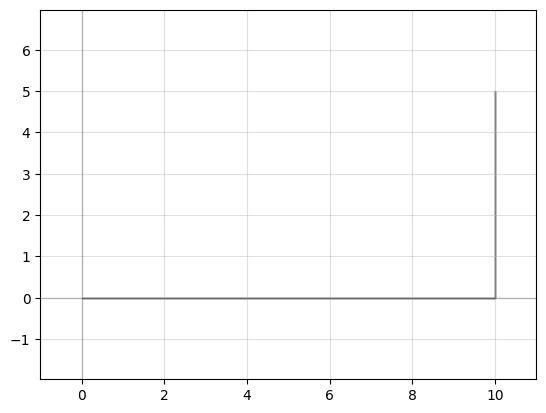

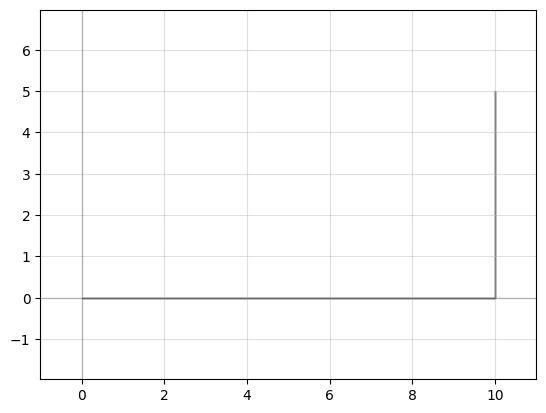

In [61]:
qp(D)
qp(D.move((10, 10)))

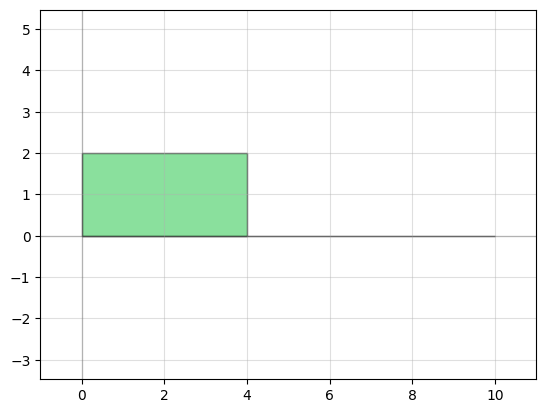

In [62]:
Two_Point_Poly= Device('two point poly')

Two_Point_Poly.add_polygon(points=[(0, 0), (10, 0)])
Two_Point_Poly << pg.rectangle()

qp(Two_Point_Poly)

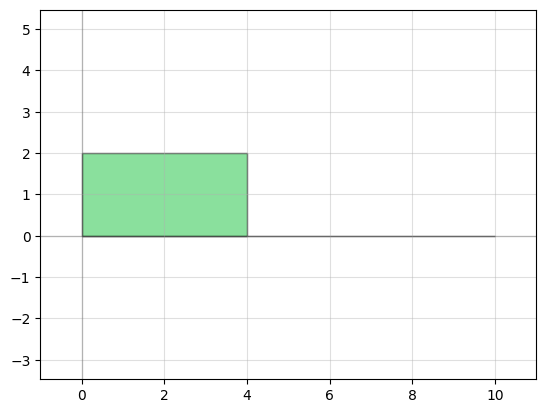

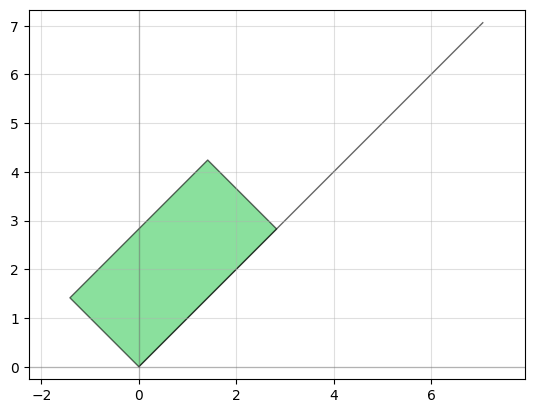

In [63]:
qp(Two_Point_Poly)
qp(Two_Point_Poly.rotate())

In [64]:
for poly in Two_Point_Poly.get_polygonsets():
    print(poly)
    print(type(poly))

Polygon (2 vertices, layer 0, datatype 0)
<class 'phidl.device_layout.Polygon'>
Polygon (4 vertices, layer 0, datatype 0)
<class 'phidl.device_layout.Polygon'>


In [65]:
for poly in Two_Point_Poly.get_polygons():
    print(poly)
    print(type(poly))

[[0.         0.        ]
 [7.07106781 7.07106781]]
<class 'numpy.ndarray'>
[[ 1.41421356  4.24264069]
 [ 2.82842712  2.82842712]
 [ 0.          0.        ]
 [-1.41421356  1.41421356]]
<class 'numpy.ndarray'>


In [66]:
for poly in Two_Point_Poly.get_polygonsets():
    p: Polygon = poly
    print(p.polygons)
    print(np.shape(p.polygons))

    if np.shape(p.polygons) == (1, 2, 2):
        print('\nFound two point polygon, replace it with zero width path using gdspy?\n')


[array([[0.        , 0.        ],
       [7.07106781, 7.07106781]])]
(1, 2, 2)

Found two point polygon, replace it with zero width path using gdspy?

[array([[ 1.41421356,  4.24264069],
       [ 2.82842712,  2.82842712],
       [ 0.        ,  0.        ],
       [-1.41421356,  1.41421356]])]
(1, 4, 2)


In [67]:
for poly, poly_set in zip(Two_Point_Poly.get_polygons(), Two_Point_Poly.get_polygonsets()):
    p: Polygon = poly_set

    if np.shape(p.polygons) == (1, 2, 2):
        print('\nFound two point polygon, replace it with zero width path using gdspy.')
        print('Use remove with gdspy.PolygonSet, does not work with phidl.device_layout.Polygon?')

        print(p)
        print(type(p))

        gdspy_polyset = gdspy.PolygonSet(p.polygons, p.layers[0], p.datatypes[0])

        print(gdspy_polyset)
        print(type(gdspy_polyset))

        Two_Point_Poly.remove(gdspy_polyset)

qp(Two_Point_Poly)



Found two point polygon, replace it with zero width path using gdspy.
Use remove with gdspy.PolygonSet, does not work with phidl.device_layout.Polygon?
Polygon (2 vertices, layer 0, datatype 0)
<class 'phidl.device_layout.Polygon'>
PolygonSet (1 polygons, 2 vertices, layers [0], datatypes [0])
<class 'gdspy.polygon.PolygonSet'>


ValueError: [PHIDL] Device.remove() cannot find the
                                     item
                                     it was asked to remove in the Device:
                                     "PolygonSet (1 polygons, 2 vertices, layers [0], datatypes [0])".

## 6. Layerset

In [ ]:
from phidl import LayerSet, Layer

ls_bad = LayerSet()

layer = Layer(name='test')

ls_bad.add_layer(layer)

ls_bad.__dict__

{'_layers': {Layer (name test, GDS layer 0, GDS datatype 0, description None, color None): Layer (name Layer (name test, GDS layer 0, GDS datatype 0, description None, color None), GDS layer 0, GDS datatype 0, description None, color None)}}

Not possible to pass `Layer` instance into `LayerSet`!! Have to add layer using keyword arguments:

In [ ]:
ls = LayerSet()

ls.add_layer(name='test')

ls.__dict__

{'_layers': {'test': Layer (name test, GDS layer 0, GDS datatype 0, description None, color None)}}

## 7. Ports

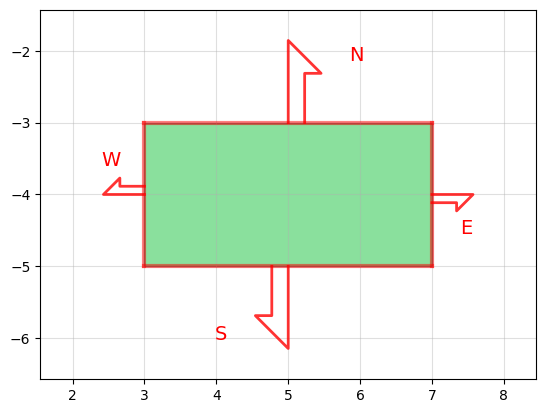

{'N': Port (name N, midpoint [ 5. -3.], width 4, orientation 90),
 'S': Port (name S, midpoint [ 5. -5.], width 4, orientation 270),
 'E': Port (name E, midpoint [ 7. -4.], width 2, orientation 0),
 'W': Port (name W, midpoint [ 3. -4.], width 2, orientation 180)}

In [ ]:
Compass =  pg.compass().move((5, -4))

qp(Compass)

Compass.ports

In [ ]:
Compass.ports['N'].midpoint

array([ 5., -3.])

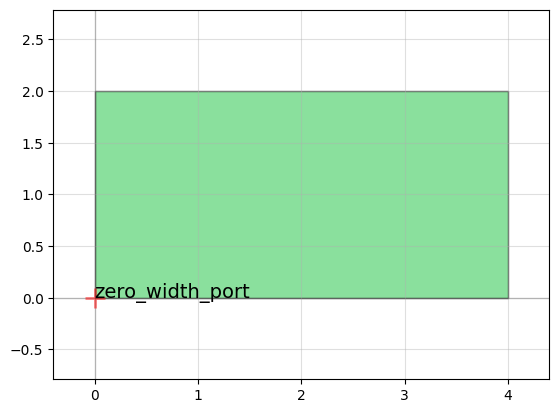

{'zero_width_port': Port (name zero_width_port, midpoint [0. 0.], width 0, orientation 45)}

In [76]:
D = Device('Device')

D << pg.rectangle()

# test zero width port
D.add_port(width=0, name='zero_width_port')

qp(D)
D.ports

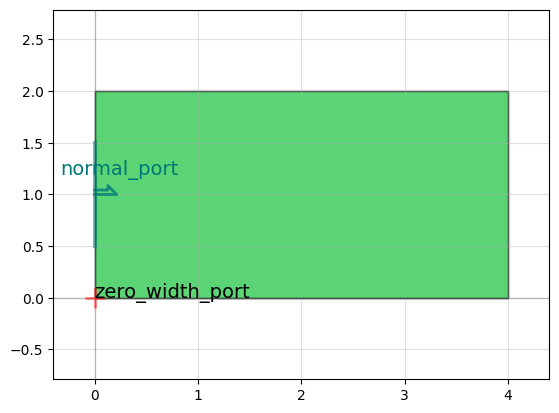

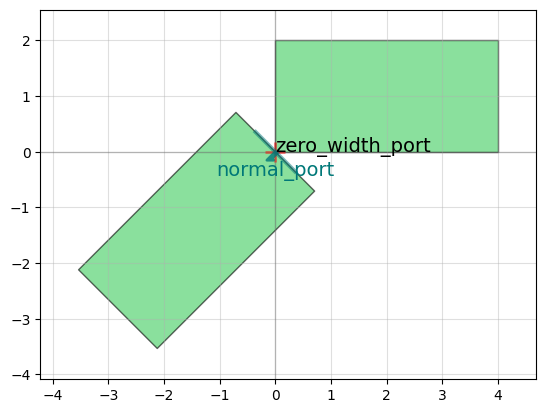

In [77]:
D2 = Device('Second device')

D2 << pg.rectangle()

D2.add_port(midpoint=(0, 1), name='normal_port', orientation=0)

d2_ref = D << D2

qp(D)

d2_ref.connect(D2.ports['normal_port'], D.ports['zero_width_port'])

qp(D)